<a href="https://colab.research.google.com/github/shadmanr1/Milestone_1/blob/main/Week_4_Notebook_Shadman_Raakin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import (LinearRegression,Ridge,Lasso,ElasticNet)
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (mean_squared_error,mean_absolute_error,r2_score)

#Dataset: Movie Box office (2000-2024)
General overview of the dataset is that it provides a detailed analysis of global box office performance from 2000 to 2024. It includes information on movies released during this period, covering key metrics such as release dates, genres, production budgets, worldwide gross, and more. The dataset aims to assist researchers, data scientists, and movie enthusiasts in exploring trends in the film industry, analyzing profitability, and understanding audience preferences over the years. https://www.kaggle.com/datasets/aditya126/movies-box-office-dataset-2000-2024?select=enhanced_box_office_data%282000-2024%29u.csv

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving enhanced_box_office_data(2000-2024)u.csv to enhanced_box_office_data(2000-2024)u.csv


In [ ]:
df = pd.read_csv("enhanced_box_office_data(2000-2024)u.csv")
df.head()

,Rank,Release Group,$Worldwide,$Domestic,Domestic %,$Foreign,Foreign %,Year,Genres,Rating,Vote_Count,Original_Language,Production_Countries
0,1,Mission: Impossible II,546388108.0,215409889.0,39.4,330978219.0,60.6,2000,"Adventure, Action, Thriller",6.126/10,6741.0,en,United States of America
1,2,Gladiator,460583960.0,187705427.0,40.8,272878533.0,59.2,2000,"Action, Drama, Adventure",8.217/10,19032.0,en,"United Kingdom, United States of America"
2,3,Cast Away,429632142.0,233632142.0,54.4,196000000.0,45.6,2000,"Adventure, Drama",7.663/10,11403.0,en,United States of America
3,4,What Women Want,374111707.0,182811707.0,48.9,191300000.0,51.1,2000,"Comedy, Romance",6.45/10,3944.0,en,"United Kingdom, United States of America"
4,5,Dinosaur,349822765.0,137748063.0,39.4,212074702.0,60.6,2000,"Animation, Family, Adventure",6.544/10,2530.0,en,United States of America


In [ ]:
df = df.dropna()

In [ ]:
df['Rating'] = (df['Rating'].str.replace('/10','').astype(float))

Above vs Below Median Revenue

In [ ]:
median_rev = df['$Worldwide'].median()
df['High_Revenue'] = (df['$Worldwide'] > median_rev).astype(int)

In [ ]:
X = df[['Year','Rating','Vote_Count']]
y = df['High_Revenue']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

Logistic Regression without scaling

In [ ]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
pred = logreg.predict(X_test)

With scaling

In [ ]:
logreg_scaled = LogisticRegression()
logreg_scaled.fit(X_train_scaled,y_train)
pred_scaled = logreg_scaled.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import (accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix)

In [ ]:
print(accuracy_score(y_test,pred_scaled))
print(precision_score(y_test,pred_scaled))
print(recall_score(y_test,pred_scaled))
print(f1_score(y_test,pred_scaled))

0.7583333333333333
0.8186528497409327
0.6610878661087866
0.7314814814814815


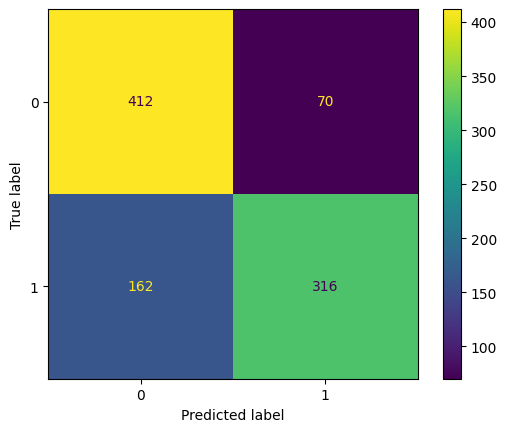

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test,pred_scaled)
plt.show()

Feature scaling improved/stabilized logistic regression performance because the predictors were measured on different scales. Vote count is much larger numerically than year or rating, so standardization ensures that no single variable dominates the optimization process.